In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [6]:
winedata=pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv', sep=';')

In [7]:
winedata

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [8]:
print(winedata.shape)

(4898, 12)


In [5]:
winedata.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Unnamed: 12,Unnamed: 13
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881,-0.113663,NaN,NaN
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718,-0.194723,NaN,NaN
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729,-0.009209,NaN,NaN
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631,-0.097577,NaN,NaN
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189,-0.209934,NaN,NaN
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104,0.008158,NaN,NaN
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892,-0.174737,NaN,NaN
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138,-0.307123,NaN,NaN
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432,0.099427,NaN,NaN
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433,0.053678,NaN,NaN


In [19]:
x=winedata.iloc[:,:-1]
y=winedata.iloc[:, 11]

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=1)

In [21]:
x_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3749,6.3,0.28,0.29,6.8,0.051,40.0,143.0,0.99374,3.43,0.59,11.0
1344,7.3,0.23,0.37,1.9,0.041,51.0,165.0,0.99080,3.26,0.40,12.2
58,6.6,0.38,0.15,4.6,0.044,25.0,78.0,0.99310,3.11,0.38,10.2
3177,5.6,0.41,0.22,7.1,0.050,44.0,154.0,0.99310,3.30,0.40,10.5
3942,7.2,0.23,0.39,1.5,0.053,26.0,106.0,0.99166,3.18,0.47,11.1


In [22]:
y_train.head()

3749    6
1344    8
58      6
3177    5
3942    6
Name: quality, dtype: int64

In [23]:
x_train.shape
x_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
2414,6.2,0.38,0.18,7.4,0.095,28.0,195.0,0.99773,3.53,0.71,9.2
1584,6.4,0.25,0.74,7.8,0.045,52.0,209.0,0.99560,3.21,0.42,9.2
3248,6.4,0.25,0.37,4.5,0.039,41.0,147.0,0.99210,3.18,0.40,11.1
645,6.3,0.26,0.25,7.8,0.058,44.0,166.0,0.99610,3.24,0.41,9.0
3163,7.1,0.36,0.37,4.8,0.019,39.0,114.0,0.99036,3.08,0.49,12.7


In [24]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(3918, 11) (980, 11) (3918,) (980,)


In [25]:
model= LogisticRegression(solver = 'lbfgs')
model.fit(x_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='lbfgs', tol=0.0001,
          verbose=0, warm_start=False)

In [26]:
y_pred = model.predict(x_test)

In [27]:
count_misclassified = (y_test != y_pred).sum()
print('Misclassified samples: {}'.format(count_misclassified))
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy: {:.2f}'.format(accuracy))

Misclassified samples: 477
Accuracy: 0.51


In [28]:
from sklearn.metrics import confusion_matrix
cnf_matrix = metrics.confusion_matrix(y_test,y_pred)
print ('Below is the confusion matrix')
print(cnf_matrix) #are incorrect predictions

Below is the confusion matrix
[[  0   0   1   1   0   0]
 [  0   0  18  10   1   0]
 [  0   0 145 146   2   0]
 [  0   0  85 342   8   0]
 [  0   0   4 164  16   0]
 [  0   0   0  33   4   0]]


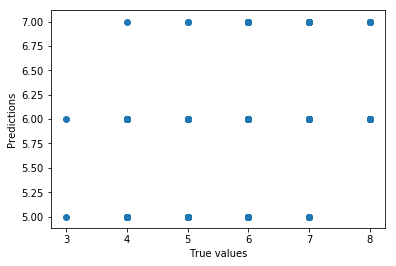

In [29]:
predictions = model.predict(x_test)
import matplotlib.pyplot as plt
plt.scatter(y_test,predictions)
plt.xlabel('True values')
plt.ylabel('Predictions')
plt.show()

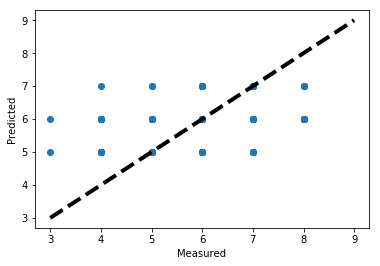

In [30]:
fig, ax = plt.subplots()
ax.scatter(y_test, predictions)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

In [31]:
new_observation=[6.7,0.15,0.38,1.7,0.037,20,84,0.99046,3.09,0.53,11.4]

In [32]:
y_pred = model.predict([new_observation])

In [33]:
probability = model.predict_proba([new_observation])

In [34]:
print('Qualit for the given values is :', y_pred)
print('Probability of the given value :', probability)

Qualit for the given values is : [6]
Probability of the given value : [[0.00179025 0.01891895 0.07299463 0.55321596 0.31408374 0.03770593
  0.00129054]]


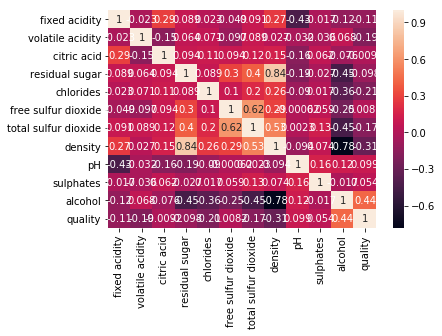

In [37]:
import seaborn as sns
corr=winedata.corr()
sns.heatmap(corr, annot = True)